<a href="https://colab.research.google.com/github/swanjala849-Mas/Machine-Learning/blob/main/Student_Perfomance_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving student_model_evaluation_dataset.xlsx to student_model_evaluation_dataset.xlsx


In [ ]:
import pandas as pd

# Load the uploaded Excel file
df = pd.read_excel('student_model_evaluation_dataset.xlsx')

# Display the first 5 rows of the dataset
display(df.head())

,Student_ID,Study_Hours_Per_Week,Attendance_Percent,Previous_Score,Assignments_Completed_Percent,Passed
0,S001,8.2,82.3,40.1,89.4,1
1,S002,6.7,84.7,55.0,64.2,0
2,S003,8.6,91.0,64.1,91.0,1
3,S004,10.8,90.6,64.7,98.3,1
4,S005,6.4,61.5,57.2,84.2,0


In [ ]:
Missing = df.isnull().sum()
print(Missing)

Student_ID                       0
Study_Hours_Per_Week             3
Attendance_Percent               3
Previous_Score                   2
Assignments_Completed_Percent    0
Passed                           0
dtype: int64


In [ ]:
# Calculate medians for columns with missing values
study_hours_median = df['Study_Hours_Per_Week'].median()
attendance_median = df['Attendance_Percent'].median()
previous_score_median = df['Previous_Score'].median()

# Fill missing values with the medians
df['Study_Hours_Per_Week'] = df['Study_Hours_Per_Week'].fillna(study_hours_median)
df['Attendance_Percent'] = df['Attendance_Percent'].fillna(attendance_median)
df['Previous_Score'] = df['Previous_Score'].fillna(previous_score_median)

In [ ]:
Missing = df.isnull().sum()
print(Missing)

Student_ID                       0
Study_Hours_Per_Week             0
Attendance_Percent               0
Previous_Score                   0
Assignments_Completed_Percent    0
Passed                           0
dtype: int64


In [ ]:
# Define features (X) and target (Y)
X = df.drop(columns=['Student_ID', 'Passed'])
y = df['Passed']



In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size= 0.3, random_state=42
    )
X_val,X_test, y_val,y_test = train_test_split(X_temp,y_temp,test_size = 0.5, random_state= 42)



In [ ]:
print(X_train.shape)
print(X_val.shape)

(140, 4)
(30, 4)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = model.predict(X_val)


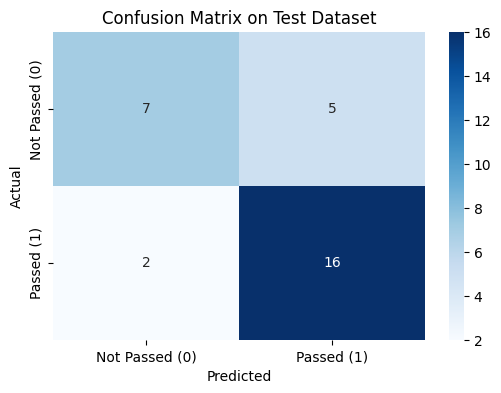

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


y_test_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Passed (0)', 'Passed (1)'],
            yticklabels=['Not Passed (0)', 'Passed (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix on Test Dataset')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Overall Model Accuracy on Test Set: {accuracy:.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_test_pred))

Overall Model Accuracy on Test Set: 0.7667

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1       0.76      0.89      0.82        18

    accuracy                           0.77        30
   macro avg       0.77      0.74      0.74        30
weighted avg       0.77      0.77      0.76        30



In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the complete dataset (X, y)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# Print the results
print(f"Scores for each of the 5 folds: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

Scores for each of the 5 folds: [0.775 0.75  0.775 0.725 0.8  ]
Mean CV Accuracy: 0.7650
Standard Deviation of CV Accuracy: 0.0255


ROC AUC Score on Test Set: 0.7963


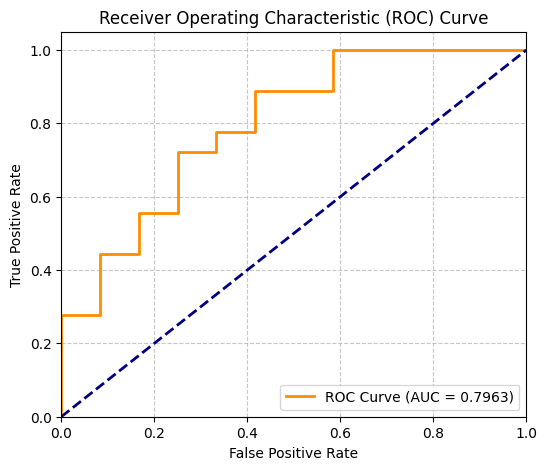

In [19]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Generate predicted probabilities for the positive class (Passed = 1)
y_test_prob = model.predict_proba(X_test)[:, 1]

# Calculate AUC
auc_score = roc_auc_score(y_test, y_test_prob)
print(f"ROC AUC Score on Test Set: {auc_score:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Is the Model Suitable for Predicting Student Performance?
Yes the model is suitable for predicting student perfomance because:

#### 1. **Overall Performance**
* **Accuracy (76.67%):** The model correctly predicts whether a student passes or fails roughly 77% of the time on the unseen test dataset. While not perfect, this provides a solid baseline.
* **ROC AUC Score (0.7963):** An AUC of approximately **0.80** indicates a **good level of discriminative power**. This means there is an 80% chance that the model will correctly distinguish a student who passes from one who does not.

#### 2. Classification Report
Looking at the test set predictions:
* **Class 0 (Did Not Pass):**
  * **Recall is 58%**: The model only successfully identifies 58% of the students who actually failed. This is a potential weakness; it means 42% of struggling students are missed (False Negatives for failing).
  * **Precision is 78%**: When the model predicts a student will fail, it is correct about 78% of the time.
* **Class 1 (Passed):**
  * **Recall is 89%**: The model is highly effective at identifying students who will pass.
  * **Precision is 76%**: When predicting a student will pass, it is correct about 76% of the time.



